<a href="https://colab.research.google.com/github/nhartman94/scaling-laws-demo/blob/main/notebooks/02_double_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Click the badge above to run this notebook in Google Colab. Then run the setup cell below first.*

In [ ]:
# === Colab setup — run this first. Does nothing when run locally. ===
import sys, os
if "google.colab" in sys.modules:
    REPO = "/content/scaling-laws-demo"
    if not os.path.exists(REPO):
        !git clone -q https://github.com/nhartman94/scaling-laws-demo.git {REPO}
    # editable install: installs deps + lets edits to scaling_laws/*.py hot-reload
    %pip install -q -e {REPO}
    # add repo to sys.path so the import works in THIS kernel (no restart needed:
    # an editable install's .pth is only read at interpreter startup)
    if REPO not in sys.path:
        sys.path.insert(0, REPO)
    # cd into notebooks/ so the ../results relative paths resolve
    %cd {REPO}/notebooks


# Double descent

The scaling-law notebook trains **single-pass**: every example is seen once, so the model
never overfits and the loss is monotone. This notebook does the opposite: **repeat a fixed
dataset to interpolation**, with extra label noise ($\sigma=0.4$), on the same Gaussian
teacher–student ($W{=}256$, $L{=}2$). That's the data-bottlenecked / overfitting regime, and it's where **double descent** lives.

Test loss here is MSE against held-out *noisy* labels $y=f(x)+\sigma\varepsilon$, so it carries the same irreducible floor $E=\sigma^2$ as the train loss and the two are directly comparable (we compute it as the noise-free excess risk $+\,\sigma^2$). The test peak always sits where the model *just* manages to fit the noisy training points. Each plot also overlays the **early-stopped** risk (the *minimum* test loss over training, an oracle early stop).

> Training happens in `scripts/run_double_descent.py` (`--mode samples|width|epochs`); this
> notebook reloads the cached CSVs and plots them.

In [1]:
import sys
# Colab: ensure the cloned repo is importable even if the setup cell above is stale
if "google.colab" in sys.modules and "/content/scaling-laws-demo" not in sys.path:
    sys.path.insert(0, "/content/scaling-laws-demo")

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from scaling_laws import plotting as pl
pl.set_style()

RESULTS = Path("../results").resolve(); FIGDIR = RESULTS / "figures"
SIGMA = 0.4
df_s = pd.read_csv(os.path.join(RESULTS, "double_descent_samples.csv"))
df_w = pd.read_csv(os.path.join(RESULTS, "double_descent_width.csv"))
df_e = pd.read_csv(os.path.join(RESULTS, "double_descent_epochs.csv"))
N256 = int(df_s["N"].iloc[0])                 # params of the W=256 model
print(f"W=256 has N={N256:,} params;  sigma={SIGMA} (noise var {SIGMA**2})")

W=256 has N=74,497 params;  sigma=0.4 (noise var 0.16000000000000003)


## 1. Model-wise — vary the width $W$

**Protocol.** Fix the dataset ($D{=}10{,}000$) and sweep the width $W$ (i.e. $N$),
training each to interpolation ([`run_double_descent.py --mode width`](../scripts/run_double_descent.py)).

**What you see.** The classic shape: a U-shaped (classical) descent, a sharp peak **exactly at the
interpolation threshold $N\approx D$** (here $W{\approx}80$, where train error collapses to ~0),
then a **second descent** deep into the overparameterised regime. Early stopping (green) again
flattens the peak.

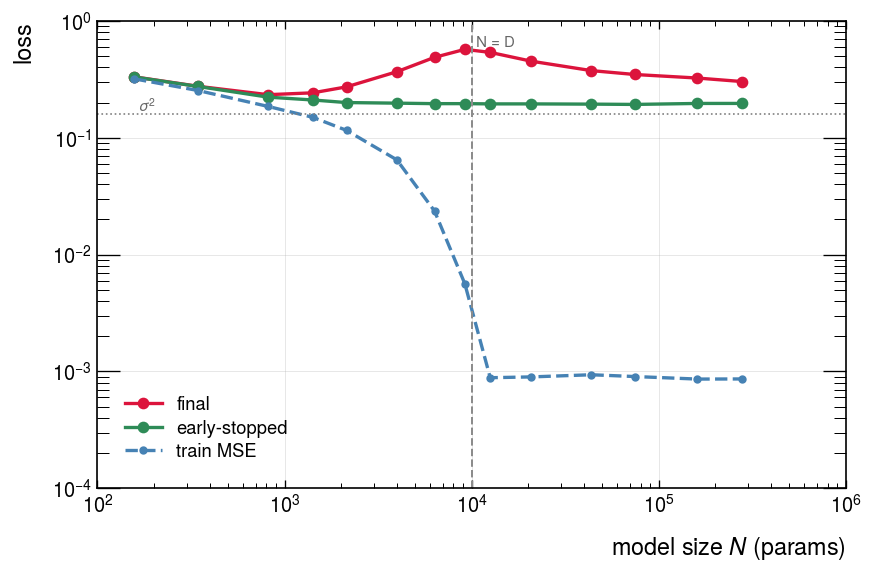

In [2]:
Dfix = int(df_w["D"].iloc[0])
fig = pl.plot_dd_final(df_w, axis="N", threshold=Dfix, threshold_label="N = D", sigma=SIGMA, train="overlay")
pl.save_figure(fig, "double_descent_width", outdir=FIGDIR); plt.show()

## 2. Sample-wise — vary the dataset size $D$

**Protocol.** Now hold the model fixed ($W{=}256$) and sweep the size $D$ of a *fixed, repeated* dataset;
train each to interpolation, recording both the **final** test risk and the **early-stopped**
(best-over-training) risk ([`run_double_descent.py --mode samples`](../scripts/run_double_descent.py)).

**What you see.** Test loss rises to a peak near the interpolation threshold $D\approx N$, then **second-descends** toward the $\sigma^2$ floor, the peak is
exactly where the model can *just* fit the noise. The early-stopped curve (green) skips it entirely.

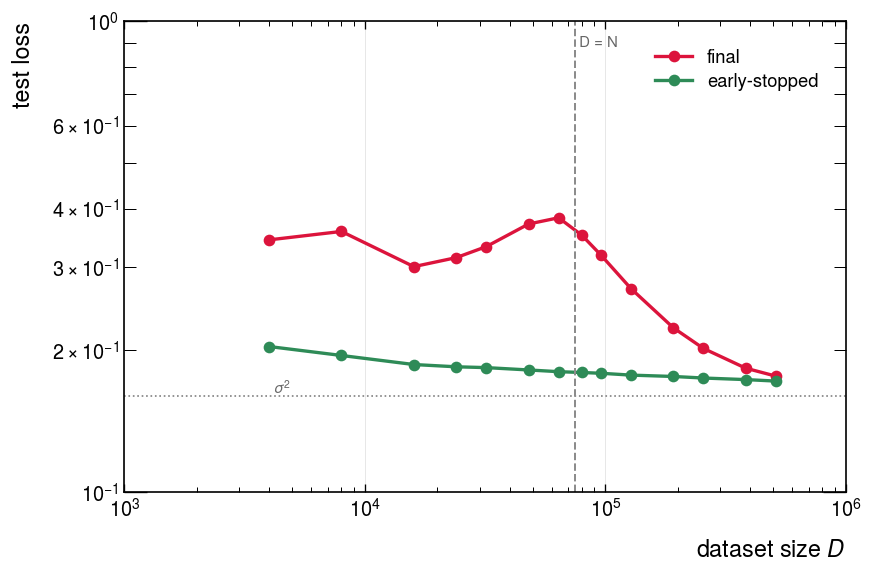

In [3]:
fig = pl.plot_dd_final(df_s, axis="D", threshold=N256, threshold_label="D = N", sigma=SIGMA, train="none")
pl.save_figure(fig, "double_descent_samples", outdir=FIGDIR); plt.show()

## 3. Epoch-wise — vary training time

**Protocol.** Fix $W{=}256$ and an overparameterised dataset and train long, **logging test and
train loss along the trajectory** ([`run_double_descent.py --mode epochs`](../scripts/run_double_descent.py)).

**What you see.** Test loss goes **down** (learn the teacher signal), **up** (memorise the
label noise), then **down** again (the second descent), while train MSE falls monotonically to
interpolation (dashed). The $\star$ marks each curve's minimum: where an early stop would land,
just before the climb.

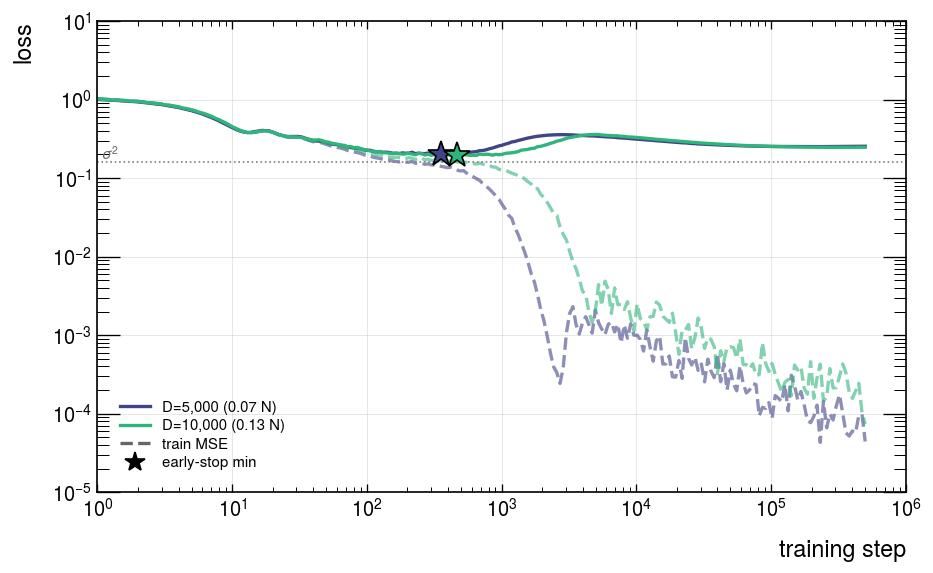

In [4]:
fig = pl.plot_dd_epochs(df_e, width=256, n_params=N256, sigma=SIGMA)
pl.save_figure(fig, "double_descent_epochs", outdir=FIGDIR); plt.show()

## 4. The whole picture — a 2D phase diagram

The three slices above are 1D cuts through one **2D plane: dataset size $D$ × model size $N$**.

**Protocol.** Sweep both axes (1 seed), train each $(W, D)$ cell to interpolation, and record
the final test loss and train MSE
([`run_double_descent.py --mode grid`](../scripts/run_double_descent.py)).

**What you see.** A bright **ridge of high test error along $N\approx D$** (dashed): the
interpolation threshold is exactly where the train MSE (right panel) collapses to zero. Step off
the ridge in either direction, by adding more data (up) or more capacity (right), and the error
**second-descends**. The model-wise and sample-wise plots above are just a vertical and a
horizontal cut through this surface.

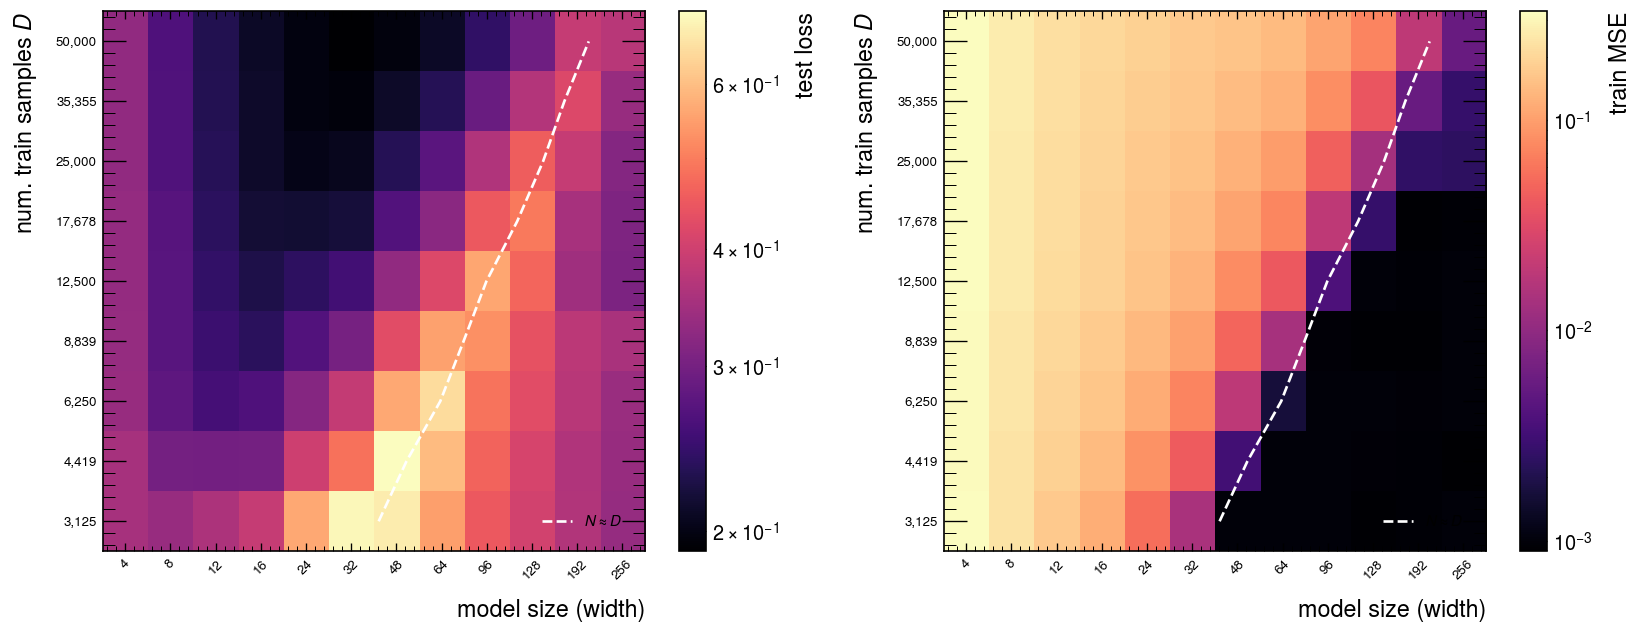

In [5]:
df_g = pd.read_csv(os.path.join(RESULTS, "double_descent_grid.csv"))
fig = pl.plot_dd_phase(df_g, sigma=SIGMA)
pl.save_figure(fig, "double_descent_phase", outdir=FIGDIR); plt.show()

## Takeaways

- **Three knobs, one phenomenon.** Whether you increase data ($D$), capacity ($N$), or
  training time, test error spikes exactly at the **interpolation threshold**, where the
  model can *just* fit the noisy data, and recovers beyond it (the second descent).
- **The train-loss panel is the tell.** In every case the test peak coincides with train
  error reaching zero.
- **Early stopping erases the peak.** The green curve / stars are the *early-stopped* risk (best test loss over training). It is nearly flat through the threshold, stopping at the test minimum erases the peak.
- **The scaling tutorial avoids all of this by construction**: single-pass training never
  repeats data, so it never interpolates a finite set, and the loss stays monotone. Double
  descent is a property of the *repeated-data* regime, not of model size per se.

### Reproduce
```bash
python scripts/run_double_descent.py --mode width     # ~6 min
python scripts/run_double_descent.py --mode samples   # ~25 min
python scripts/run_double_descent.py --mode epochs --max-steps 500000   # ~40 min
```